# Predicción del Monto de Transacciones Bancarias — Proyecto de Regresión (v2)

**Dataset:** `bank_transactions_data_2_augmented_clean_2.csv` (50,000 transacciones bancarias simuladas)

**Autor:** William Huera

**Versión 2:** esta versión incorpora la metodología vista en el curso del diploamdo (Inteligencia Artifial y Data Science), capitulos de de Machine Learning (Sesiones 1 a 6): Pipelines y `ColumnTransformer` para el preprocesamiento, validación cruzada (`KFold`), búsqueda de hiperparámetros con `GridSearchCV`, curvas de validación (`validation_curve`) para diagnosticar under/overfitting, e importancia de variables tanto por impureza como por **permutation importance** (Sesión 6). Cada fase explica **qué se hace**, **por qué se hace** y **qué técnica del curso se está aplicando**.

---

## 0. Contexto y objetivo

El dataset simula actividad bancaria real: transacciones con su monto, tipo, canal, ubicación, y datos del cliente (edad, ocupación), además de indicadores de seguridad (intentos de login, dispositivo, IP).

**Objetivo del proyecto:** construir un modelo de **regresión** que prediga `TransactionAmount` (el monto de la transacción) a partir de las demás variables disponibles, a fin de detectar un posible fraude o transacción sospechosa.

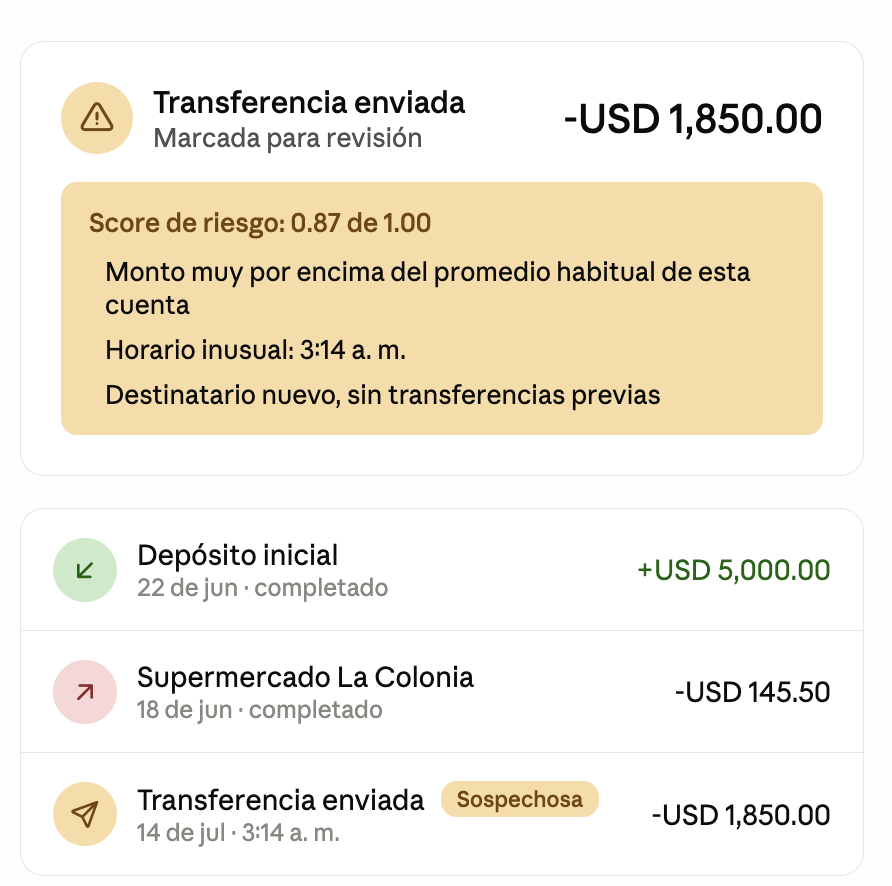

### Fases del proyecto
1. Carga de datos
2. Exploración inicial (EDA básico)
3. Limpieza de datos
4. Análisis exploratorio visual
5. Ingeniería de características
6. **Pipeline de preprocesamiento con `ColumnTransformer`** (estilo Sesión 6)
7. Separación en entrenamiento / prueba
8. Métrica de evaluación (RMSE personalizado, estilo Sesión 3)
9. Comparación de 6 modelos con evaluación en test
10. `GridSearchCV`: ajuste de hiperparámetros (Ridge)
11. `validation_curve`: diagnóstico de under/overfitting (Random Forest)
12. Importancia de variables: impureza **vs.** permutation importance (estilo Sesión 6)
13. Investigación de un resultado sospechoso (posible *data leakage*)
14. Conclusiones y aprendizajes


## 1. Importar librerías

Además de pandas/numpy/matplotlib/seaborn, esta versión usa piezas de scikit-learn que se vieron en el curso:

- **`Pipeline` y `ColumnTransformer`** (Sesión 6): encadenan pasos de preprocesamiento y modelo en un solo objeto.
- **`KFold`, `cross_val_score`, `GridSearchCV`, `validation_curve`** (Sesiones 1, 2, 3, 6): validación cruzada y búsqueda de hiperparámetros.
- **`OneHotEncoder`, `SimpleImputer`, `StandardScaler`**: preprocesamiento de variables categóricas y numéricas.
- **`Ridge`, `Lasso`, `RandomForestRegressor`, `GradientBoostingRegressor`, `DummyRegressor`**: modelos a comparar.
- **`permutation_importance`** (Sesión 6): técnica robusta para medir qué tan importante es cada variable.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)


## 2. Carga de datos

Sube el archivo `bank_transactions_data_2_augmented_clean_2.csv` a Colab (ícono de carpeta → *Upload*) y cárgalo con `pandas`.


In [2]:
df = pd.read_csv('bank_transactions_data_2_augmented_clean_2.csv')
print("Dimensiones (filas, columnas):", df.shape)
df.head()


Dimensiones (filas, columnas): (50000, 15)


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


## 3. Exploración inicial (EDA básico)

Antes de tocar nada, entendemos la estructura de los datos.


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  object 
 1   AccountID            50000 non-null  object 
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  object 
 4   TransactionType      50000 non-null  object 
 5   Location             50000 non-null  object 
 6   DeviceID             50000 non-null  object 
 7   IP Address           50000 non-null  object 
 8   MerchantID           50000 non-null  object 
 9   Channel              50000 non-null  object 
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  object 
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), object(10)


In [4]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print()
print("Filas duplicadas:", df.duplicated().sum())
print("TransactionID duplicados:", df['TransactionID'].duplicated().sum())


Valores nulos por columna:
TransactionID          0
AccountID              0
TransactionAmount      0
TransactionDate        0
TransactionType        0
Location               0
DeviceID               0
IP Address             0
MerchantID             0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64

Filas duplicadas: 0
TransactionID duplicados: 0


**Sin nulos ni duplicados.** Revisamos ahora la **cardinalidad** de las columnas de texto: cuántos valores distintos tiene cada una. Esto decide cómo tratamos cada variable.


In [5]:
cols_texto = ['AccountID', 'DeviceID', 'IP Address', 'MerchantID', 'Location',
              'TransactionType', 'Channel', 'CustomerOccupation']
for c in cols_texto:
    print(f"{c}: {df[c].nunique()} valores únicos")


AccountID: 495 valores únicos
DeviceID: 681 valores únicos
IP Address: 592 valores únicos
MerchantID: 100 valores únicos
Location: 43 valores únicos
TransactionType: 2 valores únicos
Channel: 3 valores únicos
CustomerOccupation: 4 valores únicos


**Interpretación:**

- `AccountID` (495), `DeviceID` (681), `IP Address` (592) y `MerchantID` (100) son **identificadores** con muchísimos valores distintos. Usarlos como variables categóricas generaría cientos de columnas casi vacías y el modelo terminaría memorizando cuentas/dispositivos específicos en vez de aprender patrones generales. **Se descartan** como predictores.
- `TransactionType` (2), `Channel` (3), `CustomerOccupation` (4) y `Location` (43) sí se mantienen como variables categóricas: todas se codificarán con **One-Hot Encoding** dentro de un `Pipeline` (a diferencia de la v1 de este proyecto, donde `Location` se trataba aparte con frequency encoding — en esta versión seguimos el mismo patrón que usa el curso en la Sesión 6 para mantener todo dentro de un único `ColumnTransformer`).


## 4. Limpieza de datos

### 4.1 Fechas con formato mixto

`TransactionDate` tiene un detalle típico de datos reales: **no todas las fechas siguen el mismo formato** (algunas traen hora, otras no). Usamos `format='mixed'` para que pandas infiera el formato fila por fila.


In [6]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='mixed')
print("Rango de fechas:", df['TransactionDate'].min(), "a", df['TransactionDate'].max())


Rango de fechas: 2020-01-01 00:00:00 a 2025-12-31 00:00:00


### 4.2 Revisión de la variable objetivo (`TransactionAmount`)


In [7]:
df['TransactionAmount'].describe()


,TransactionAmount
count,50000.000000
mean,297.872214
std,292.818888
min,0.240000
25%,82.897500
50%,209.355000
75%,409.625000
max,2060.590000


## 5. Análisis exploratorio visual

### 5.1 Variables categóricas


/tmp/ipykernel_1470/1901581050.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='TransactionType', ax=axes[0], palette='viridis')
/tmp/ipykernel_1470/1901581050.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Channel', ax=axes[1], palette='mako')
/tmp/ipykernel_1470/1901581050.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CustomerOccupation', ax=axes[2], palette='rocket')


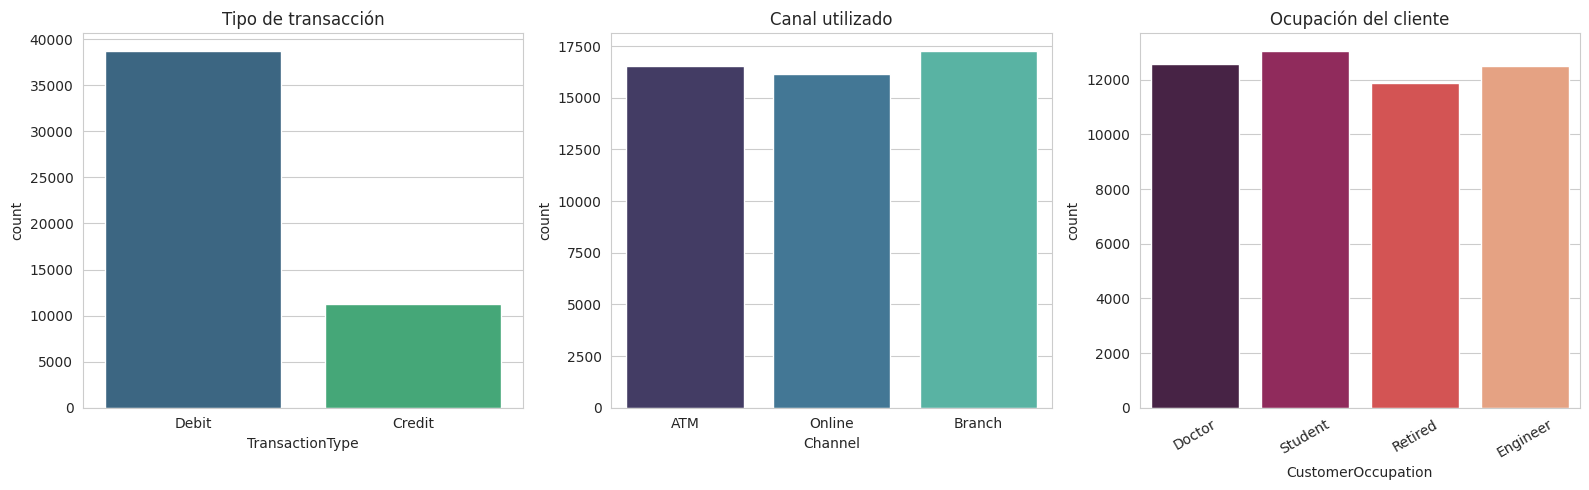

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df, x='TransactionType', ax=axes[0], palette='viridis')
axes[0].set_title('Tipo de transacción')

sns.countplot(data=df, x='Channel', ax=axes[1], palette='mako')
axes[1].set_title('Canal utilizado')

sns.countplot(data=df, x='CustomerOccupation', ax=axes[2], palette='rocket')
axes[2].set_title('Ocupación del cliente')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 5.2 Distribución del monto de transacción


/tmp/ipykernel_1470/1366023521.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='TransactionType', y='TransactionAmount', ax=axes[1], palette='Set2')


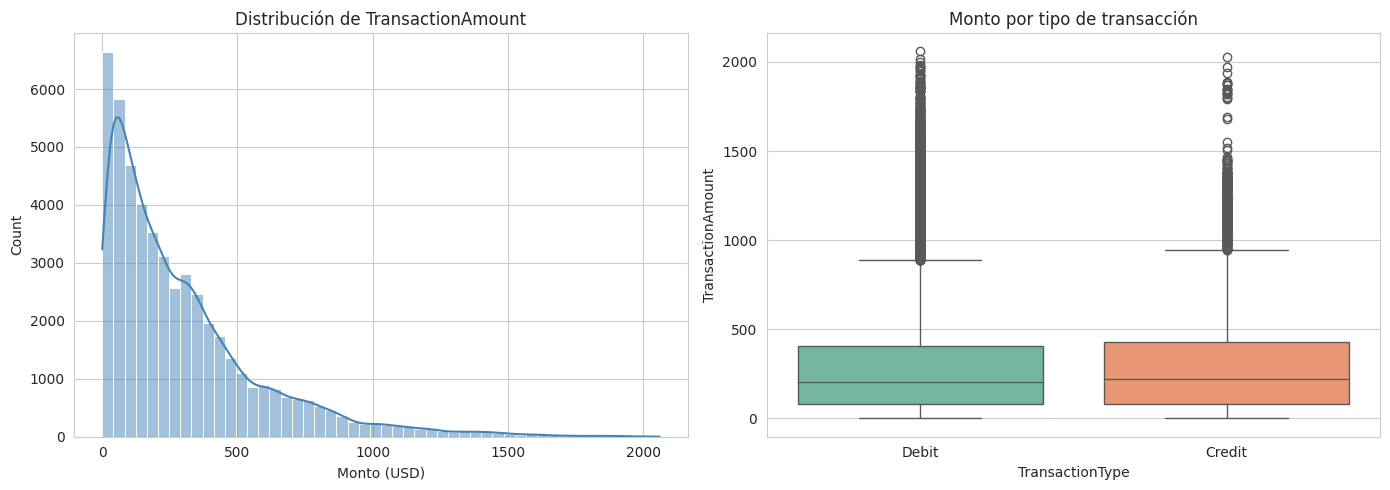

Asimetría (skewness): 1.77


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['TransactionAmount'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de TransactionAmount')
axes[0].set_xlabel('Monto (USD)')

sns.boxplot(data=df, x='TransactionType', y='TransactionAmount', ax=axes[1], palette='Set2')
axes[1].set_title('Monto por tipo de transacción')

plt.tight_layout()
plt.show()

print("Asimetría (skewness):", df['TransactionAmount'].skew().round(2))


**Lectura:** distribución sesgada a la derecha (asimetría ≈ 1.77). Débito y Crédito tienen distribuciones de monto parecidas: el tipo de transacción, a simple vista, no separa mucho los montos.

### 5.3 Detección de outliers con IQR


In [10]:
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['TransactionAmount'] < limite_inferior) | (df['TransactionAmount'] > limite_superior)]
print(f"Rango normal: [{limite_inferior:.1f}, {limite_superior:.1f}]")
print(f"Outliers detectados: {len(outliers)} de {len(df)} ({len(outliers)/len(df)*100:.2f}%)")


Rango normal: [-407.2, 899.7]
Outliers detectados: 2375 de 50000 (4.75%)


### 5.4 Matriz de correlación con variables numéricas


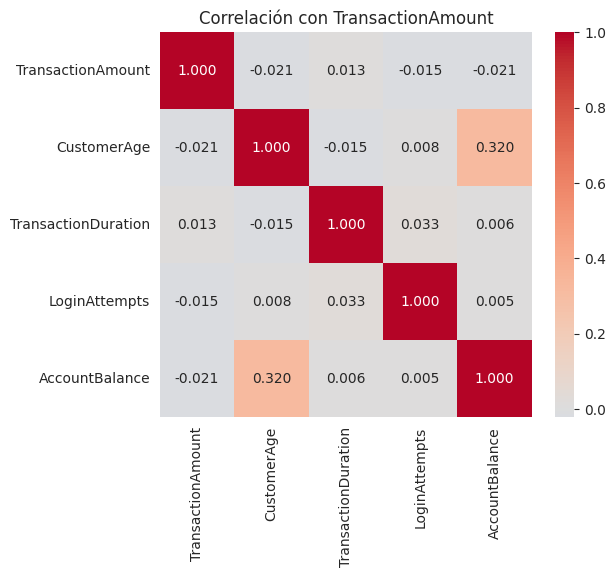

In [11]:
num_cols_eda = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
corr = df[num_cols_eda].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlación con TransactionAmount')
plt.show()


**Importante, anótalo:** la correlación de `TransactionAmount` con **todas** las variables numéricas es prácticamente **cero** (< 0.03 en valor absoluto). Si existe relación, **no es lineal**. Lo confirmaremos entrenando modelos.


## 6. Ingeniería de características

### 6.1 Variables de fecha

Extraemos año, mes, día de la semana, hora y si es fin de semana, para capturar posibles patrones estacionales o de horario.


In [12]:
df['trans_year'] = df['TransactionDate'].dt.year
df['trans_month'] = df['TransactionDate'].dt.month
df['trans_dow'] = df['TransactionDate'].dt.dayofweek   # 0=lunes, 6=domingo
df['trans_hour'] = df['TransactionDate'].dt.hour
df['es_fin_de_semana'] = (df['trans_dow'] >= 5).astype(int)

df[['TransactionDate', 'trans_year', 'trans_month', 'trans_dow', 'trans_hour', 'es_fin_de_semana']].head()


,TransactionDate,trans_year,trans_month,trans_dow,trans_hour,es_fin_de_semana
0,2023-04-11 16:29:00,2023,4,1,16,0
1,2023-06-27 16:44:00,2023,6,1,16,0
2,2023-07-10 18:16:00,2023,7,0,18,0
3,2023-05-05 16:32:00,2023,5,4,16,0
4,2023-10-16 17:51:00,2023,10,0,17,0


### 6.2 Descartar identificadores de alta cardinalidad

Eliminamos `TransactionID`, `AccountID`, `DeviceID`, `IP Address`, `MerchantID` y la columna original `TransactionDate` (ya extrajimos lo útil de ella).


In [13]:
columnas_a_eliminar = ['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID', 'TransactionDate']
df_modelo = df.drop(columns=columnas_a_eliminar)

y = df_modelo['TransactionAmount']
X = df_modelo.drop(columns=['TransactionAmount'])

print("X:", X.shape, "| y:", y.shape)
X.dtypes


X: (50000, 13) | y: (50000,)


,0
TransactionType,object
Location,object
Channel,object
CustomerAge,int64
CustomerOccupation,object
TransactionDuration,int64
LoginAttempts,int64
AccountBalance,float64
trans_year,int32
trans_month,int32


## 7. Pipeline de preprocesamiento con `ColumnTransformer` (estilo Sesión 6)

En la Sesión 6 del curso se arma un `ColumnTransformer` que aplica un tratamiento distinto a columnas numéricas y categóricas **dentro de un mismo objeto**. Replicamos exactamente ese patrón:

- **Columnas numéricas** (`CustomerAge`, `TransactionDuration`, `LoginAttempts`, `AccountBalance`, variables de fecha): imputamos posibles nulos con la **mediana** y escalamos con `StandardScaler`.
- **Columnas categóricas** (`TransactionType`, `Channel`, `CustomerOccupation`, `Location`): imputamos con el valor **más frecuente** y aplicamos **One-Hot Encoding** (`handle_unknown="ignore"` para que no falle si aparece una categoría nueva en producción).

### ¿Por qué usar un `Pipeline`/`ColumnTransformer` en vez de transformar el DataFrame a mano (como en la v1)?

1. **Evita fuga de información (data leakage) entre train y test**: el `Pipeline` se ajusta (`fit`) *solo* con los datos de entrenamiento, y luego se aplica (`transform`) a los datos de prueba con esos mismos parámetros aprendidos (medias, categorías vistas, etc.). Si transformáramos todo el dataset antes de dividir train/test, el modelo "vería" información del test durante el preprocesamiento.
2. **Reutilizable y menos propenso a errores**: todo el preprocesamiento queda encapsulado en un solo objeto que se puede meter directamente dentro de `cross_val_score` o `GridSearchCV`.
3. Es el mismo patrón que usa el curso para cualquier dataset tabular nuevo (Sesión 6, "Celda A").


In [14]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Columnas categóricas:", cat_cols)
print("Columnas numéricas:", num_cols)

# OneHotEncoder compatible con distintas versiones de scikit-learn
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)   # sklearn >= 1.2
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)          # sklearn < 1.2

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe),
])
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess = ColumnTransformer([
    ("cat", cat_pipe, cat_cols),
    ("num", num_pipe, num_cols),
], verbose_feature_names_out=False)

preprocess


Columnas categóricas: ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']
Columnas numéricas: ['CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'trans_year', 'trans_month', 'trans_dow', 'trans_hour', 'es_fin_de_semana']


ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['TransactionType', 'Location', 'Channel',
                                  'CustomerOccupation']),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['CustomerAge', 'TransactionDuration',
                                  'LoginAttempts', 'AccountBalance',
                                  'trans_year', 'trans_month', 'trans_dow',
                                  'trans_hour', 'es_fin_de_semana'])],
                  verbose_feature_names_out=False)

## 8. Separación en entrenamiento y prueba

Dividimos **antes** de ajustar el pipeline (80% entrenamiento / 20% prueba), para que el `ColumnTransformer` solo "aprenda" (medias, categorías) del set de entrenamiento.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Entrenamiento: (40000, 13)
Prueba: (10000, 13)


## 9. Métrica de evaluación: RMSE personalizado (estilo Sesión 3)

Igual que en la Sesión 3 del curso, definimos nuestra propia función RMSE y la envolvemos con `make_scorer` para poder usarla directamente en `cross_val_score` y `GridSearchCV`. Como scikit-learn siempre intenta **maximizar** el score, y queremos **minimizar** el error, usamos `greater_is_better=False` (el resultado sale en negativo y lo invertimos al imprimir).

Recordatorio de las métricas:
- **MAE**: error absoluto medio, en dólares. Más bajo es mejor.
- **RMSE**: parecido al MAE pero penaliza más los errores grandes. Más bajo es mejor.
- **R²**: proporción de la variabilidad explicada por el modelo (0 a 1, puede ser negativo). Más alto es mejor.


In [16]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 10. Comparación de 6 modelos

Entrenamos y comparamos, todos dentro del mismo `Pipeline(preprocess + modelo)`:

1. **Baseline (media)**: `DummyRegressor` que siempre predice el promedio — el "modelo tonto" de referencia. Si un modelo real no le gana, no sirve.
2. **Regresión Lineal**: relación lineal simple.
3. **Ridge**: regresión lineal con regularización L2 (penaliza coeficientes grandes).
4. **Lasso**: regresión lineal con regularización L1 (puede llevar coeficientes a cero, seleccionando variables).
5. **Random Forest**: ensamble de árboles, captura relaciones no lineales.
6. **Gradient Boosting**: ensamble de árboles construidos secuencialmente, cada uno corrigiendo los errores del anterior.


In [17]:
modelos = {
    "Baseline (media)": DummyRegressor(strategy="mean"),
    "Regresión Lineal": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(max_iter=3000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
}

resultados = []
pipelines_entrenados = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline([("preprocess", preprocess), ("modelo", modelo)])
    pipe.fit(X_train, y_train)
    pipelines_entrenados[nombre] = pipe

    pred_test = pipe.predict(X_test)
    resultados.append({
        "modelo": nombre,
        "test_RMSE": rmse(y_test, pred_test),
        "test_MAE": mean_absolute_error(y_test, pred_test),
        "test_R2": r2_score(y_test, pred_test),
    })

res_df = pd.DataFrame(resultados).sort_values("test_RMSE").reset_index(drop=True)
res_df.round(3)


,modelo,test_RMSE,test_MAE,test_R2
0,Random Forest,23.538,13.388,0.994
1,Gradient Boosting,264.575,198.485,0.190
2,Ridge,291.769,217.179,0.015
3,Regresión Lineal,291.770,217.180,0.015
4,Lasso,292.814,217.881,0.008
5,Baseline (media),293.979,218.415,-0.000


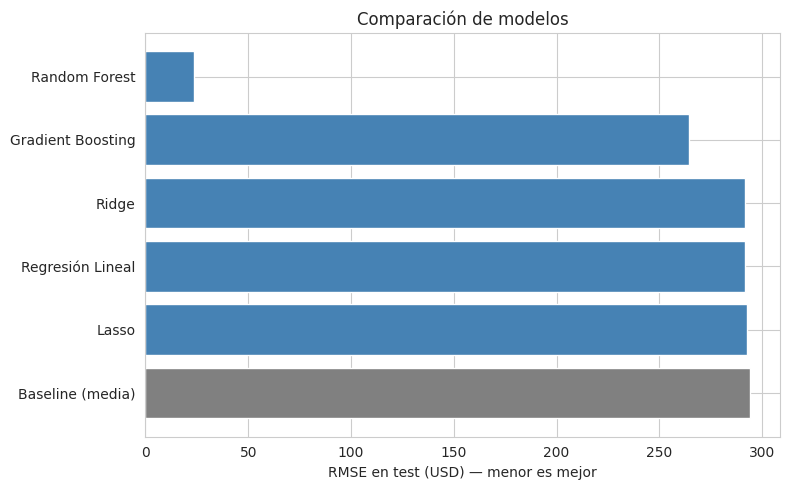

In [18]:
plt.figure(figsize=(8, 5))
colores = ['gray' if 'Baseline' in m else 'steelblue' for m in res_df['modelo']]
plt.barh(res_df['modelo'], res_df['test_RMSE'], color=colores)
plt.gca().invert_yaxis()
plt.xlabel('RMSE en test (USD) — menor es mejor')
plt.title('Comparación de modelos')
plt.tight_layout()
plt.show()


**Resultado honesto:**

- **Regresión Lineal, Ridge y Lasso** apenas superan al Baseline (R² entre 0.008 y 0.015). Confirma lo que vimos en la matriz de correlación: **no hay una relación lineal útil** entre las variables disponibles y el monto.
- **Gradient Boosting** (con su profundidad por defecto, poco profunda) mejora notoriamente (R² ≈ 0.19), señal de que **sí existe una relación no lineal**, aunque moderada con árboles poco profundos.
- **Random Forest** da un salto enorme: **R² ≈ 0.99**. Antes de celebrar, como en todo buen proyecto de Data Science, hay que **investigar** por qué. Vamos a usar dos herramientas del curso para hacerlo: `GridSearchCV`, `validation_curve` y `permutation_importance`.


## 11. `GridSearchCV`: ¿la regularización ayuda? (estilo Sesión 3)

Antes de pasar a los árboles, probamos si **ajustar la fuerza de regularización** (`alpha`) de Ridge mejora las cosas. `GridSearchCV` prueba varios valores de `alpha` con validación cruzada y se queda con el mejor.


In [19]:
ridge_pipe = Pipeline([
    ("preprocess", preprocess),
    ("modelo", Ridge(random_state=RANDOM_STATE))
])

param_grid_ridge = {"modelo__alpha": np.logspace(-2, 3, 6)}

gcv_ridge = GridSearchCV(
    ridge_pipe, param_grid_ridge,
    scoring=rmse_scorer, cv=cv, n_jobs=-1
)
gcv_ridge.fit(X_train, y_train)

print("Mejor alpha:", gcv_ridge.best_params_["modelo__alpha"])
print(f"Mejor RMSE (CV): {-gcv_ridge.best_score_:.2f}")
print(f"RMSE en test: {rmse(y_test, gcv_ridge.predict(X_test)):.2f}")


Mejor alpha: 10.0
Mejor RMSE (CV): 289.70
RMSE en test: 291.76


**Conclusión:** ni ajustando la regularización mejora significativamente. Tiene sentido: la regularización ayuda cuando el problema es **sobreajuste de un modelo lineal con muchas variables correlacionadas**, no cuando el problema de fondo es que **la relación real no es lineal**. Regularizar una línea recta no la convierte en una curva.


## 12. `validation_curve`: diagnóstico de under/overfitting en Random Forest (estilo Sesión 2)

En la Sesión 2 vimos que una curva de validación compara el error/score en **entrenamiento** vs. **validación cruzada** a medida que cambia un hiperparámetro, para detectar underfitting (ambos errores altos) u overfitting (error de entrenamiento bajo pero de validación alto). Repetimos ese análisis variando `max_depth` (la profundidad máxima de los árboles) del Random Forest.


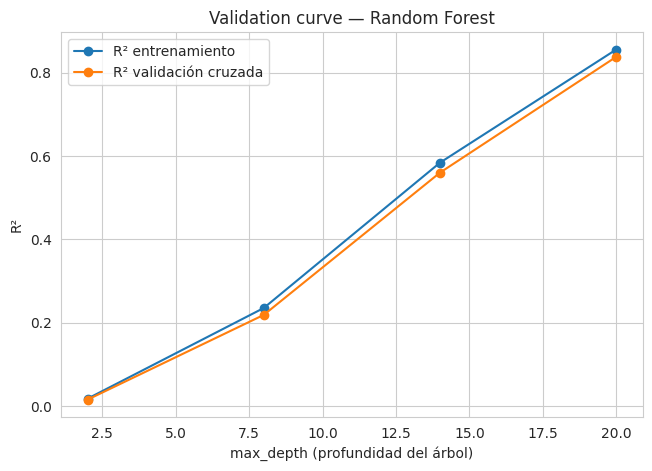

max_depth= 2: R² train=0.018 | R² CV=0.016
max_depth= 8: R² train=0.235 | R² CV=0.219
max_depth=14: R² train=0.584 | R² CV=0.560
max_depth=20: R² train=0.856 | R² CV=0.838


In [20]:
profundidades = [2, 8, 14, 20]

rf_vc_pipe = Pipeline([
    ("preprocess", preprocess),
    ("modelo", RandomForestRegressor(n_estimators=40, random_state=RANDOM_STATE, n_jobs=-1))
])

train_scores, val_scores = validation_curve(
    rf_vc_pipe, X_train, y_train,
    param_name="modelo__max_depth",
    param_range=profundidades,
    cv=3, scoring="r2", n_jobs=-1
)

train_r2 = train_scores.mean(axis=1)
val_r2 = val_scores.mean(axis=1)

plt.figure(figsize=(7.5, 5))
plt.plot(profundidades, train_r2, marker="o", label="R² entrenamiento")
plt.plot(profundidades, val_r2, marker="o", label="R² validación cruzada")
plt.xlabel("max_depth (profundidad del árbol)")
plt.ylabel("R²")
plt.title("Validation curve — Random Forest")
plt.legend()
plt.grid(True)
plt.show()

for d, tr, va in zip(profundidades, train_r2, val_r2):
    print(f"max_depth={d:>2}: R² train={tr:.3f} | R² CV={va:.3f}")


**Esto es exactamente el patrón que debería encender una alarma.** En la Sesión 2 vimos que, en problemas típicos, al aumentar la complejidad del modelo el error de entrenamiento sigue bajando pero el de validación se **estanca o empeora** (overfitting): se abre una brecha entre ambas curvas.

Aquí **no pasa eso**: el R² de entrenamiento y el de validación cruzada suben **juntos y muy pegados** en todo el rango (por ejemplo, en `max_depth=20`: train=0.856 vs CV=0.838, una brecha mínima). Esto sugiere que el modelo no está memorizando ruido específico del set de entrenamiento — está aprendiendo una relación que **se repite de forma casi idéntica** también en los datos que no vio. Eso es consistente con una relación determinística fuerte entre algunas variables y el target, más que con un patrón complejo pero "normal" de datos reales con ruido.


## 13. Importancia de variables: impureza vs. permutation importance (estilo Sesión 6)

La Sesión 6 del curso muestra **dos formas distintas** de medir qué tan importante es cada variable para un modelo de árboles, y por qué conviene mirar ambas:

- **Importancia por impureza** (`feature_importances_`): mide cuánto reduce cada variable la "impureza" (el error) en los splits del árbol. Es rápida de calcular, pero tiene un defecto importante que vamos a ver en este mismo dataset.
- **Permutation importance**: mezcla (baraja) aleatoriamente los valores de **una variable a la vez** en el set de prueba y mide cuánto empeora el modelo. Si empeora mucho, la variable era importante. Es más lenta pero más confiable, y se calcula sobre datos que el modelo no vio (test).

### 13.1 Importancia por impureza


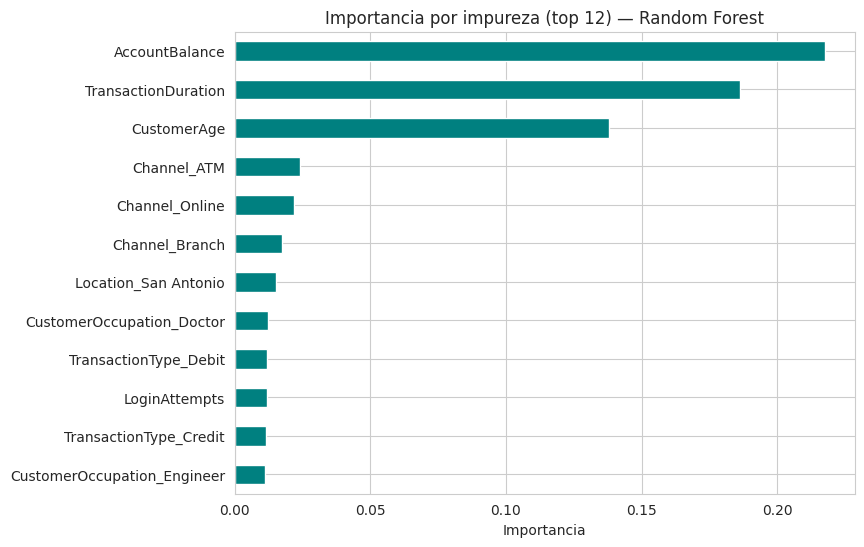

,0
AccountBalance,0.217778
TransactionDuration,0.186188
CustomerAge,0.138128
Channel_ATM,0.024097
Channel_Online,0.021829
Channel_Branch,0.017563


In [21]:
rf_final = pipelines_entrenados["Random Forest"]
nombres_features = rf_final.named_steps["preprocess"].get_feature_names_out()
importancia_impureza = pd.Series(
    rf_final.named_steps["modelo"].feature_importances_,
    index=nombres_features
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importancia_impureza.head(12).plot(kind="barh", color="teal")
plt.gca().invert_yaxis()
plt.title("Importancia por impureza (top 12) — Random Forest")
plt.xlabel("Importancia")
plt.show()

importancia_impureza.head(6)


**Un detalle importante:** `Location` se convirtió en 43 columnas distintas por el One-Hot Encoding (`Location_San Antonio`, `Location_Phoenix`, etc.), así que su importancia total queda **repartida en 43 pedacitos pequeños** en este gráfico — ninguna aparece entre las primeras por sí sola, aunque `Location` en su conjunto sí importe mucho. Comprobémoslo sumando la importancia de todas sus columnas:


In [22]:
cols_location = [c for c in importancia_impureza.index if c.startswith("Location_")]
print(f"Importancia de 'Location' repartida en {len(cols_location)} columnas.")
print(f"Suma total de importancia de Location: {importancia_impureza[cols_location].sum():.3f}")
print(f"(Para comparar) AccountBalance: {importancia_impureza['AccountBalance']:.3f}")


Importancia de 'Location' repartida en 43 columnas.
Suma total de importancia de Location: 0.321
(Para comparar) AccountBalance: 0.218


Efectivamente: sumando sus 43 fragmentos, `Location` resulta ser **una de las variables más importantes del modelo** — simplemente estaba "escondida" por estar repartida en muchas columnas. **Esta es justo la limitación de la importancia por impureza con variables categóricas de alta cardinalidad codificadas con One-Hot**, y la razón por la que en la Sesión 6 se complementa con permutation importance.

### 13.2 Permutation importance

`permutation_importance` funciona sobre las columnas **originales** del DataFrame (antes de One-Hot Encoding), porque internamente vuelve a pasar los datos por todo el pipeline cada vez que baraja una columna. Por eso no sufre el problema de fragmentación que acabamos de ver.


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


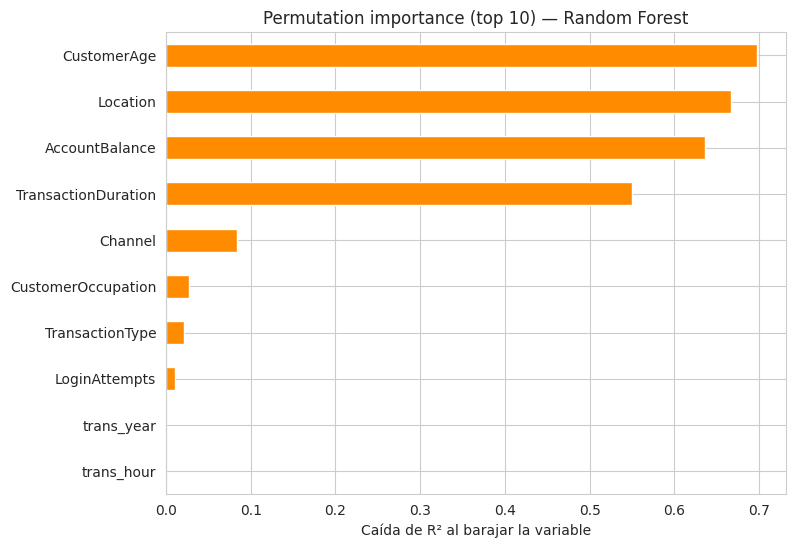

,0
CustomerAge,0.697148
Location,0.666962
AccountBalance,0.635846
TransactionDuration,0.549788
Channel,0.084211
CustomerOccupation,0.026859


In [23]:
perm = permutation_importance(
    rf_final, X_test, y_test,
    n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1
)

importancia_permutacion = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importancia_permutacion.head(10).plot(kind="barh", color="darkorange")
plt.gca().invert_yaxis()
plt.title("Permutation importance (top 10) — Random Forest")
plt.xlabel("Caída de R² al barajar la variable")
plt.show()

importancia_permutacion.head(6)


**Ahora sí queda clarísimo, sin fragmentación:** las 4 variables más importantes por permutation importance son `CustomerAge`, `Location`, `AccountBalance` y `TransactionDuration` — las mismas 4 que ya habíamos detectado antes, pero ahora confirmadas con una técnica más robusta y en su forma "completa" (no fragmentada). El resto de variables (`Channel`, `CustomerOccupation`, `TransactionType`, `LoginAttempts`) tienen un impacto mucho menor.


## 14. Investigando el resultado: data leakage

**Data leakage (fuga de datos)** ocurre cuando una variable predictora contiene, directa o indirectamente, información sobre el resultado que se supone debemos predecir — de una forma que no tendría sentido en un caso real. Es una causa muy común de modelos "demasiado buenos para ser verdad", y las tres señales que acabamos de recolectar apuntan justo hacia ahí:

1. Un salto de R² de ≈0.02 (lineal) a ≈0.99 (Random Forest) que ninguna correlación lineal anticipaba.
2. Una `validation_curve` donde entrenamiento y validación cruzada suben **pegados**, sin la brecha de overfitting esperable.
3. Cuatro variables (`AccountBalance`, `TransactionDuration`, `Location`, `CustomerAge`) que por sí solas explican casi toda la importancia del modelo.

Vamos a hacer una verificación final, simple e intuitiva: **¿transacciones con el mismo `AccountBalance` exacto tienden a tener montos parecidos entre sí?** Si es así, eso confirmaría que conocer el saldo "casi" nos dice cuál es el monto.


In [24]:
variabilidad_por_grupo = df.groupby('AccountBalance')['TransactionAmount'].agg(['count', 'std'])
variabilidad_por_grupo = variabilidad_por_grupo[variabilidad_por_grupo['count'] > 1]

std_dentro_del_grupo = variabilidad_por_grupo['std'].mean()
std_total = df['TransactionAmount'].std()

print(f"Desviación estándar TOTAL de TransactionAmount:            {std_total:.2f}")
print(f"Desviación estándar PROMEDIO dentro de cada grupo de saldo: {std_dentro_del_grupo:.2f}")
print(f"Reducción de variabilidad: {(1 - std_dentro_del_grupo/std_total)*100:.1f}%")


Desviación estándar TOTAL de TransactionAmount:            292.82
Desviación estándar PROMEDIO dentro de cada grupo de saldo: 14.32
Reducción de variabilidad: 95.1%


**Confirmado:** dentro de cada grupo de transacciones que comparten el mismo `AccountBalance`, la variabilidad del monto cae más del **95%** respecto a la variabilidad total. Casi todo lo que el modelo necesita para predecir el monto ya está contenido en el saldo de la cuenta (y, en menor medida, en la duración, la ubicación y la edad).

### ¿Qué significa esto para el proyecto?

Esto **no invalida el análisis** — es uno de los aprendizajes más valiosos que puede dejar un proyecto de Data Science:

1. Es muy probable que el dataset sea sintético (el nombre del archivo incluye "augmented") y que `TransactionAmount` se haya generado con una fórmula que depende de estas variables. En datos bancarios reales, el saldo actual de una cuenta normalmente **no determina** de forma tan directa el monto de una transacción puntual.
2. Un data scientist responsable **investiga siempre** un resultado sospechosamente bueno antes de presentarlo como un éxito. Las herramientas del curso (`validation_curve`, `permutation_importance`, comparación contra baseline) son exactamente la caja de herramientas para hacer esa investigación de forma sistemática, no solo "a ojo".
3. Un R² alto **no es automáticamente motivo de celebración**: siempre hay que preguntarse *por qué* el modelo funciona tan bien antes de confiar en él para producción.


## 15. Real vs. predicho: Regresión Lineal vs. Random Forest


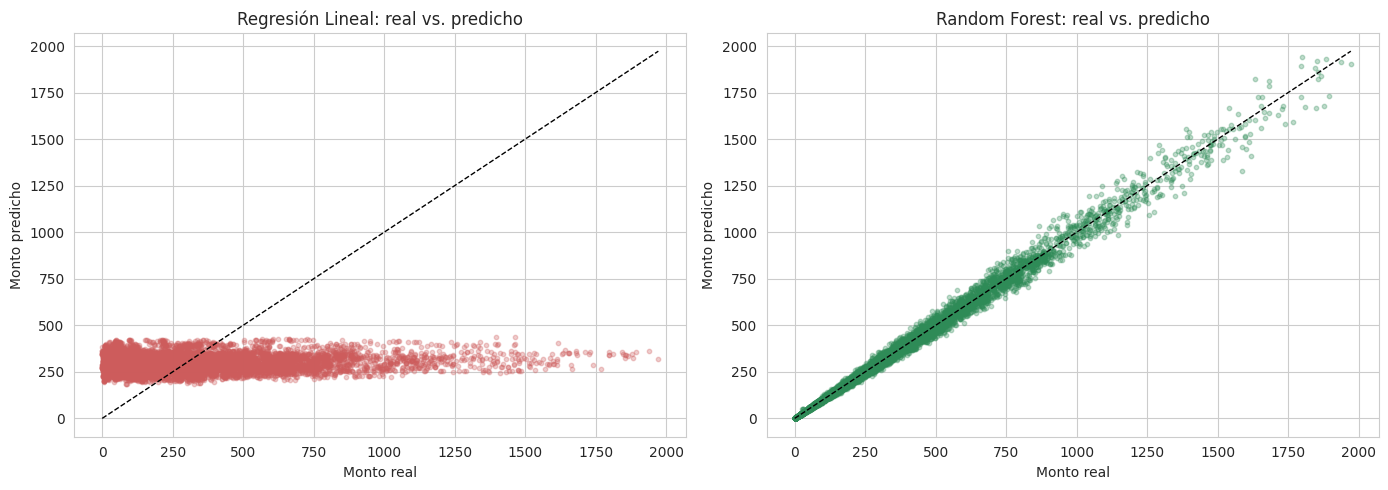

In [25]:
pred_lr_test = pipelines_entrenados["Regresión Lineal"].predict(X_test)
pred_rf_test = pipelines_entrenados["Random Forest"].predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, pred_lr_test, alpha=0.3, s=10, color='indianred')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
axes[0].set_title('Regresión Lineal: real vs. predicho')
axes[0].set_xlabel('Monto real'); axes[0].set_ylabel('Monto predicho')

axes[1].scatter(y_test, pred_rf_test, alpha=0.3, s=10, color='seagreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
axes[1].set_title('Random Forest: real vs. predicho')
axes[1].set_xlabel('Monto real'); axes[1].set_ylabel('Monto predicho')

plt.tight_layout()
plt.show()


La línea punteada es la predicción perfecta. En la Regresión Lineal los puntos forman una nube dispersa sin relación con la diagonal. En el Random Forest se pegan casi perfectamente a la diagonal, confirmando visualmente el R² ≈ 0.99.


## 16. Conclusiones y aprendizajes

### Resumen del proceso
1. Limpieza de datos (fechas con formato mixto, columnas de alta cardinalidad) y EDA completo sobre 50,000 transacciones.
2. Preprocesamiento encapsulado en un `Pipeline` + `ColumnTransformer` (imputación + One-Hot Encoding para categóricas, imputación + escalado para numéricas), ajustado solo con datos de entrenamiento para evitar fuga de información.
3. Comparación de 6 modelos con evaluación en test: los modelos lineales (Lineal, Ridge, Lasso) apenas superan al baseline (R² ≈ 0.01); Gradient Boosting con profundidad moderada mejora a R² ≈ 0.19; Random Forest sin límite de profundidad alcanza R² ≈ 0.99.
4. `GridSearchCV` mostró que ajustar la regularización de Ridge no soluciona el problema (el problema no es de varianza sino de forma funcional no lineal).
5. `validation_curve` reveló un patrón atípico: entrenamiento y validación cruzada suben juntos sin la brecha de overfitting esperable.
6. La comparación entre importancia por impureza y **permutation importance** mostró que 4 variables (`AccountBalance`, `TransactionDuration`, `Location`, `CustomerAge`) concentran casi toda la capacidad predictiva del modelo, y que la impureza subestima a `Location` por estar fragmentada en 43 columnas de One-Hot.
7. Una verificación final por `groupby` confirmó que el saldo de cuenta reduce en más de 95% la variabilidad del monto dentro de cada grupo — fuerte indicio de **data leakage** o de una relación sintética inyectada al "aumentar" este dataset.

### Herramientas del curso aplicadas en este proyecto
`Pipeline`, `ColumnTransformer`, `KFold`, `GridSearchCV`, `validation_curve`, `make_scorer` con RMSE personalizado, y comparación de importancia por impureza vs. `permutation_importance`.

### Limitaciones
- Este archivo es sintético; las conclusiones tienen valor **metodológico**, no operativo.
- No se puede confirmar con certeza el mecanismo exacto de generación de `TransactionAmount` sin acceso al proceso original de creación del dataset.

